# Agentic RAG with LangGraph + Google Gemini

A production-style Agentic RAG pipeline built with LangGraph and Google Gemini AI.
The system decides whether to retrieve, grades retrieved documents for relevance,
rewrites the query if documents are irrelevant, and verifies the final answer
is grounded in context — not hallucinated.

**Pipeline:**
```
User Question
     ↓
Decide Retrieval  ──(no retrieval needed)──→ Generate → Hallucination Check → Answer
     ↓ (retrieval needed)
Retrieve Documents (FAISS)
     ↓
Grade Documents  ──(irrelevant)──→ Rewrite Query ──→ back to Retrieve
     ↓ (relevant)
Generate Answer
     ↓
Hallucination Check  ──(hallucinated)──→ Regenerate
     ↓ (grounded)
Final Answer
```

## 0. Install Dependencies

Run this once in your terminal before opening the notebook:
```bash
pip install langgraph langchain langchain-google-genai langchain-community faiss-cpu python-dotenv
```

## 1. Imports and Setup

In [31]:
import os
from typing import TypedDict, List, Literal
from dotenv import load_dotenv

from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

# gemini-1.5-flash is fast and free-tier friendly
# swap to gemini-1.5-pro for better reasoning on complex questions
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,          # deterministic decisions in routing nodes
    convert_system_message_to_human=True  # Gemini requires this
)

embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
    
)

print("Gemini LLM and embeddings ready.")
try:
    test_vector = embeddings.embed_query("Is this working?")
    print("Success! The embedding model is finally responding properly.")
except Exception as e:
    print(f"Still failing. Error details: {e}")

Gemini LLM and embeddings ready.
Success! The embedding model is finally responding properly.


## 2. Graph State

The `AgentState` is the single source of truth passed between every node.
Each node reads from it and returns an updated copy — nothing is stored globally.

In [14]:
class AgentState(TypedDict):
    question: str                 # original user question
    rewritten_question: str       # improved query after a failed retrieval
    documents: List[Document]     # docs that passed relevance grading
    answer: str                   # generated answer
    needs_retrieval: bool         # did Gemini decide retrieval is necessary?
    retrieval_attempts: int       # loop counter — prevents infinite retries
    hallucination_detected: bool  # did the grounding check flag the answer?

## 3. Vector Store

We use FAISS for fast in-memory similarity search with Gemini embeddings.
In a real project, replace `sample_texts` with documents loaded via
`PyPDFLoader`, `WebBaseLoader`, or any LangChain document loader.

In [15]:
sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs. "
    "It extends LangChain with the ability to coordinate multiple chains across multiple "
    "steps of computation in a cyclic manner, enabling complex agentic workflows.",

    "RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval "
    "with text generation. It retrieves relevant documents from a knowledge base and uses them "
    "as context so the LLM can generate more accurate, grounded responses.",

    "Vector databases store high-dimensional embedding vectors and enable efficient semantic "
    "similarity search. FAISS (Facebook AI Similarity Search) is a popular open-source library "
    "for this purpose, supporting both exact and approximate nearest-neighbour search.",

    "Agentic systems are AI systems that can take actions, make decisions, and interact with "
    "their environment autonomously. They combine planning, tool use, and iterative reasoning "
    "to complete complex multi-step tasks.",

    "Hallucination in LLMs refers to the model generating confident-sounding statements that "
    "are factually incorrect or unsupported by the provided context. Grounding checks verify "
    "that generated answers are supported by retrieved documents.",

    "Query rewriting is a technique where an LLM reformulates a poorly-worded or ambiguous "
    "user question into a clearer, more search-friendly version to improve retrieval quality.",

    "Document grading in RAG pipelines involves using an LLM to evaluate whether a retrieved "
    "document is actually relevant to the user's question. Irrelevant documents are filtered "
    "out before reaching the generation step.",
]

# Split into smaller chunks for better retrieval granularity
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
docs = splitter.create_documents(sample_texts)

vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"Vector store ready — {len(docs)} chunks indexed with Gemini embeddings.")

Vector store ready — 7 chunks indexed with Gemini embeddings.


## 4. Node Functions

Each function is a **node** in the graph. Nodes receive the full state,
do one focused job, and return only the updated fields.

### Node 1 — Decide Retrieval
Gemini reasons about whether the question needs external documents.
This is what separates agentic RAG from basic RAG — the model
judges its own knowledge gaps instead of always retrieving blindly.

In [16]:
def decide_retrieval(state: AgentState) -> AgentState:
    """
    Node 1: Gemini-based retrieval decision.

    The model evaluates whether the question needs external knowledge
    or can be answered from general training data alone.
    Sets 'needs_retrieval' to True or False in the state.
    """
    question = state["question"]

    prompt = f"""You are a routing assistant. Decide whether the following question
requires searching a knowledge base (retrieval) or can be answered
directly from general knowledge.

Question: {question}

Rules:
- Answer YES if the question is about specific technical topics, documents,
  domain knowledge, or anything that benefits from external context.
- Answer NO only for simple greetings, basic math, or trivially general questions.

Reply with exactly one word: YES or NO."""

    response = llm.invoke(prompt)
    decision = response.content.strip().upper()
    needs_retrieval = "YES" in decision

    print(f"[decide_retrieval] '{question[:60]}' → Retrieve: {needs_retrieval}")

    return {
        **state,
        "needs_retrieval": needs_retrieval,
        "rewritten_question": question,
        "retrieval_attempts": 0,
        "hallucination_detected": False,
    }

### Node 2 — Retrieve Documents
Performs semantic similarity search against the FAISS index using Gemini embeddings.
Uses `rewritten_question` so after a rewrite loop, we search with the improved query.

In [17]:
def retrieve_documents(state: AgentState) -> AgentState:
    """
    Node 2: Semantic retrieval from the FAISS vector store.

    Uses rewritten_question (which may have been improved by the
    rewrite_query node in a previous loop iteration).
    Increments retrieval_attempts to track loop count.
    """
    query = state["rewritten_question"]
    retrieved_docs = retriever.invoke(query)

    print(f"[retrieve_documents] Retrieved {len(retrieved_docs)} docs | "
          f"attempt #{state['retrieval_attempts'] + 1}")

    return {
        **state,
        "documents": retrieved_docs,
        "retrieval_attempts": state["retrieval_attempts"] + 1,
    }

### Node 3 — Grade Documents
Gemini scores each retrieved document individually for relevance.
Only relevant documents reach the generator — this filters out noise
and is the key quality improvement over plain RAG.

In [18]:
def grade_documents(state: AgentState) -> AgentState:
    """
    Node 3: Gemini-based relevance grading for each retrieved document.

    Each document is evaluated individually. Only relevant ones are kept.
    If no documents survive grading, the graph routes to rewrite_query
    to try again with a better query.
    """
    question = state["question"]
    documents = state["documents"]
    relevant_docs = []

    for i, doc in enumerate(documents):
        prompt = f"""You are a document relevance grader.

Question: {question}

Document:
{doc.page_content}

Is this document relevant to answering the question?
Reply with exactly one word: YES or NO."""

        response = llm.invoke(prompt)
        grade = response.content.strip().upper()

        if "YES" in grade:
            relevant_docs.append(doc)
            print(f"[grade_documents] Doc {i+1}: RELEVANT")
        else:
            print(f"[grade_documents] Doc {i+1}: IRRELEVANT — filtered out")

    print(f"[grade_documents] {len(relevant_docs)}/{len(documents)} docs passed grading.")

    return {**state, "documents": relevant_docs}

### Node 4 — Rewrite Query
When all documents fail grading, Gemini rephrases the question to be
more precise and search-friendly. This creates the agentic feedback loop
that makes the pipeline self-correcting.

In [19]:
def rewrite_query(state: AgentState) -> AgentState:
    """
    Node 4: Gemini-based query rewriting.

    Called when all graded documents were irrelevant. Gemini rephrases
    the question to be more precise, improving the next retrieval attempt.
    The rewritten version is stored in 'rewritten_question'.
    """
    original_question = state["question"]

    prompt = f"""You are a query rewriting assistant. The previous retrieval attempt
did not find relevant documents for the question below.

Original question: {original_question}

Rewrite this question to be clearer, more specific, and more likely to match
relevant documents in a technical knowledge base. Focus on key technical terms.

Return only the rewritten question, nothing else."""

    response = llm.invoke(prompt)
    rewritten = response.content.strip()

    print(f"[rewrite_query] Original:  '{original_question}'")
    print(f"[rewrite_query] Rewritten: '{rewritten}'")

    return {**state, "rewritten_question": rewritten}

### Node 5 — Generate Answer
Builds the final answer using only the graded (relevant) documents as context.
Falls back to general knowledge if no documents were retrieved.

In [20]:
def generate_answer(state: AgentState) -> AgentState:
    """
    Node 5: Context-grounded answer generation with Gemini.

    Uses only the graded, relevant documents as context.
    Falls back to general knowledge if no documents are available
    (i.e. when needs_retrieval was False).
    """
    question = state["question"]
    documents = state.get("documents", [])

    if documents:
        context = "\n\n---\n\n".join(
            [f"Document {i+1}:\n{doc.page_content}" for i, doc in enumerate(documents)]
        )
        prompt = f"""You are a helpful assistant. Answer the question using ONLY the
information provided in the context below. If the context does not contain
enough information, say so clearly — do not invent facts.

Context:
{context}

Question: {question}

Answer:"""
    else:
        # No-retrieval path: answer directly from Gemini's knowledge
        prompt = f"Answer the following question clearly and concisely:\n\n{question}"

    response = llm.invoke(prompt)
    answer = response.content.strip()

    print(f"[generate_answer] Answer generated ({len(answer)} chars).")

    return {**state, "answer": answer}

### Node 6 — Hallucination Check
The final quality gate. Gemini verifies the answer is supported by the
retrieved context. If not, the graph routes back to regenerate the answer.

In [21]:
def check_hallucination(state: AgentState) -> AgentState:
    """
    Node 6: Hallucination / grounding check with Gemini.

    Verifies the generated answer is supported by the retrieved documents.
    Sets hallucination_detected=True if the answer contains unsupported claims.
    Skipped automatically when no documents were used (no-retrieval path).
    """
    answer = state["answer"]
    documents = state.get("documents", [])

    # No documents = answered from general knowledge, skip grounding check
    if not documents:
        print("[check_hallucination] No documents used — grounding check skipped.")
        return {**state, "hallucination_detected": False}

    context = "\n\n".join([doc.page_content for doc in documents])

    prompt = f"""You are a hallucination detection assistant.

Given the context and the generated answer below, determine whether
the answer is fully supported by the context.

Context:
{context}

Generated Answer:
{answer}

Is the answer fully grounded in (supported by) the provided context?
Reply with exactly one word: YES or NO."""

    response = llm.invoke(prompt)
    grounded = "YES" in response.content.strip().upper()
    hallucination_detected = not grounded

    status = "GROUNDED ✓" if grounded else "HALLUCINATION DETECTED ✗"
    print(f"[check_hallucination] {status}")

    return {**state, "hallucination_detected": hallucination_detected}

## 5. Conditional Edge Functions

These routing functions look at the current state and return the name
of the next node to visit. The loop logic lives here.

In [22]:
def route_after_decide(state: AgentState) -> Literal["retrieve", "generate"]:
    """After decide_retrieval: go to retrieve if needed, else skip to generate."""
    return "retrieve" if state["needs_retrieval"] else "generate"


def route_after_grading(state: AgentState) -> Literal["generate", "rewrite"]:
    """
    After grade_documents:
    - Relevant docs found            → generate answer.
    - No relevant docs, under limit  → rewrite query and retry.
    - No relevant docs, limit hit    → generate anyway (avoids infinite loop).
    """
    MAX_RETRIEVAL_ATTEMPTS = 2

    if state["documents"]:
        return "generate"

    if state["retrieval_attempts"] >= MAX_RETRIEVAL_ATTEMPTS:
        print("[route_after_grading] Max retries reached — forcing generation.")
        return "generate"

    return "rewrite"


def route_after_hallucination_check(state: AgentState) -> Literal["generate", "__end__"]:
    """
    After check_hallucination:
    - Hallucination detected → regenerate (one retry allowed).
    - Answer is grounded     → end the graph.
    """
    if state["hallucination_detected"]:
        print("[route] Hallucination detected — regenerating.")
        return "generate"
    return END

## 6. Build the LangGraph

Wire all nodes and edges together.
The dashed feedback arrows in the architecture diagram become `add_conditional_edges` here.

Graph compiled successfully.


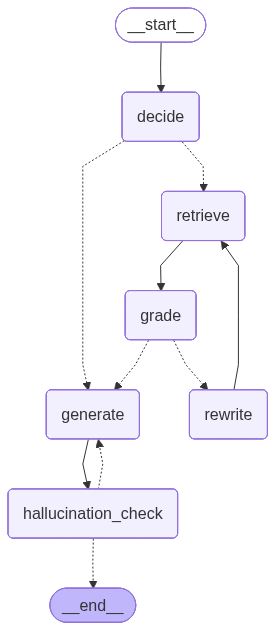

In [23]:
workflow = StateGraph(AgentState)

# ── Register nodes ───────────────────────────────────────────────────────────
workflow.add_node("decide",              decide_retrieval)
workflow.add_node("retrieve",            retrieve_documents)
workflow.add_node("grade",               grade_documents)
workflow.add_node("rewrite",             rewrite_query)
workflow.add_node("generate",            generate_answer)
workflow.add_node("hallucination_check", check_hallucination)

# ── Entry point ──────────────────────────────────────────────────────────────
workflow.set_entry_point("decide")

# ── Edges ────────────────────────────────────────────────────────────────────

# decide → retrieve OR generate (skip retrieval)
workflow.add_conditional_edges(
    "decide",
    route_after_decide,
    {"retrieve": "retrieve", "generate": "generate"}
)

# retrieve → grade (always)
workflow.add_edge("retrieve", "grade")

# grade → generate (relevant docs) OR rewrite (no relevant docs)
workflow.add_conditional_edges(
    "grade",
    route_after_grading,
    {"generate": "generate", "rewrite": "rewrite"}
)

# rewrite → retrieve (loop back with improved query)
workflow.add_edge("rewrite", "retrieve")

# generate → hallucination_check (always)
workflow.add_edge("generate", "hallucination_check")

# hallucination_check → END (grounded) OR generate (hallucinated, retry)
workflow.add_conditional_edges(
    "hallucination_check",
    route_after_hallucination_check,
    {"generate": "generate", END: END}
)

# ── Compile ──────────────────────────────────────────────────────────────────
app = workflow.compile()

print("Graph compiled successfully.")
app  # renders the graph image in Jupyter

## 7. Helper Function

In [25]:
def ask(question: str) -> dict:
    """
    Run the full Agentic RAG pipeline for a given question.
    Prints node-by-node logs and returns the complete final state.
    """
    print("\n" + "=" * 60)
    print(f"QUESTION: {question}")
    print("=" * 60)

    initial_state: AgentState = {
        "question": question,
        "rewritten_question": question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False,
        "retrieval_attempts": 0,
        "hallucination_detected": False,
    }

    result = app.invoke(initial_state)

    print("\n" + "-" * 60)
    print(f"ANSWER:\n{result['answer']}")
    print("-" * 60)
    print(
        f"Docs used: {len(result['documents'])} | "
        f"Retrieval attempts: {result['retrieval_attempts']} | "
        f"Hallucination detected: {result['hallucination_detected']}"
    )

    return result

## 8. Run Examples

### Test 1 — Technical question (retrieval triggered)

In [26]:
result1 = ask("What is LangGraph and how does it extend LangChain?")


QUESTION: What is LangGraph and how does it extend LangChain?
[decide_retrieval] 'What is LangGraph and how does it extend LangChain?' → Retrieve: True
[retrieve_documents] Retrieved 3 docs | attempt #1
[grade_documents] Doc 1: RELEVANT
[grade_documents] Doc 2: IRRELEVANT — filtered out
[grade_documents] Doc 3: IRRELEVANT — filtered out
[grade_documents] 1/3 docs passed grading.
[generate_answer] Answer generated (242 chars).
[check_hallucination] GROUNDED ✓

------------------------------------------------------------
ANSWER:
LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner, enabling complex agentic workflows.
------------------------------------------------------------
Docs used: 1 | Retrieval attempts: 1 | Hallucination detected: False


### Test 2 — Document grading and filtering

In [27]:
result2 = ask("How does document grading improve RAG pipelines?")


QUESTION: How does document grading improve RAG pipelines?
[decide_retrieval] 'How does document grading improve RAG pipelines?' → Retrieve: True
[retrieve_documents] Retrieved 3 docs | attempt #1
[grade_documents] Doc 1: RELEVANT
[grade_documents] Doc 2: IRRELEVANT — filtered out
[grade_documents] Doc 3: RELEVANT
[grade_documents] 2/3 docs passed grading.
[generate_answer] Answer generated (206 chars).
[check_hallucination] GROUNDED ✓

------------------------------------------------------------
ANSWER:
Document grading improves RAG pipelines by using an LLM to evaluate whether a retrieved document is relevant to the user's question, filtering out irrelevant documents before they reach the generation step.
------------------------------------------------------------
Docs used: 2 | Retrieval attempts: 1 | Hallucination detected: False


### Test 3 — Simple question (no-retrieval path)

In [28]:
result3 = ask("What is 2 + 2?")


QUESTION: What is 2 + 2?
[decide_retrieval] 'What is 2 + 2?' → Retrieve: False
[generate_answer] Answer generated (1 chars).
[check_hallucination] No documents used — grounding check skipped.

------------------------------------------------------------
ANSWER:
4
------------------------------------------------------------
Docs used: 0 | Retrieval attempts: 0 | Hallucination detected: False


### Test 4 — Multi-concept question (tests rewrite loop + hallucination check)

In [29]:
result4 = ask("How does query rewriting help when retrieved documents are irrelevant?")


QUESTION: How does query rewriting help when retrieved documents are irrelevant?
[decide_retrieval] 'How does query rewriting help when retrieved documents are i' → Retrieve: True
[retrieve_documents] Retrieved 3 docs | attempt #1
[grade_documents] Doc 1: RELEVANT
[grade_documents] Doc 2: IRRELEVANT — filtered out
[grade_documents] Doc 3: IRRELEVANT — filtered out
[grade_documents] 1/3 docs passed grading.
[generate_answer] Answer generated (211 chars).
[check_hallucination] GROUNDED ✓

------------------------------------------------------------
ANSWER:
Query rewriting helps when retrieved documents are irrelevant by reformulating a poorly-worded or ambiguous user question into a clearer, more search-friendly version, which is done to improve retrieval quality.
------------------------------------------------------------
Docs used: 1 | Retrieval attempts: 1 | Hallucination detected: False


## 9. Inspect the Final State

In [30]:
print("Question:          ", result1["question"])
print("Rewritten question:", result1["rewritten_question"])
print("Needs retrieval:   ", result1["needs_retrieval"])
print("Retrieval attempts:", result1["retrieval_attempts"])
print("Docs after grading:", len(result1["documents"]))
print("Hallucination:     ", result1["hallucination_detected"])
print("\nAnswer:\n", result1["answer"])

Question:           What is LangGraph and how does it extend LangChain?
Rewritten question: What is LangGraph and how does it extend LangChain?
Needs retrieval:    True
Retrieval attempts: 1
Docs after grading: 1
Hallucination:      False

Answer:
 LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner, enabling complex agentic workflows.
